## Leitura de Arquivo

In [32]:
import pandas as pd

csv_path = r"C:/Users/augus/Desktop/Projetos/youtubeCommentsAnalysis/assets/comments_data.csv"

df = pd.read_csv(csv_path)

df.head(10)

,comment
0,flávio irá ganhar a eleição alculubre fora do ...
1,vocês estão achando que milhões é caro porque ...
2,é porque no de janeiro estavam todos unidos pa...
3,típico de máfia italiana stf de bandidos
4,vamos pegar esses ministros atraves das urnas ...
5,querem saber a verdade o caso master vai dar e...
6,batoré segue dançando
7,david alcolumbre segue prevaricando que é crime
8,não coveseu dona vivi só piorou vergonha brasi...
9,e não vai ter cmpi para investigar os político...


## Tratamento dos dados

In [33]:
df = df.drop_duplicates(subset="comment")

df["comment_clean"] = df["comment"].str.strip().str.lower()

df = df[df["comment_clean"] != ""]

In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   comment        149 non-null    str  
 1   comment_clean  149 non-null    str  
dtypes: str(2)
memory usage: 3.5 KB


## Número médio de letras

In [35]:
df["num_letters"] = df["comment_clean"].apply(lambda x : len(str(x)))

media_letras = df['num_letters'].mean()
print(f'Número médio de letras: {int(media_letras)}\n')
df.info()

Número médio de letras: 112

<class 'pandas.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   comment        149 non-null    str  
 1   comment_clean  149 non-null    str  
 2   num_letters    149 non-null    int64
dtypes: int64(1), str(2)
memory usage: 4.7 KB


## 20 palavras mais comun

In [36]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\augus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
all_words = " ".join(df["comment_clean"].dropna().astype(str)).split()
filtered_words = [w for w in all_words if w not in stop_words]

word_counts = Counter(filtered_words)

print(word_counts.most_common(20))

[('israel', 17), ('irã', 15), ('eua', 14), ('stf', 13), ('vai', 13), ('pra', 13), ('agora', 12), ('trump', 12), ('pt', 11), ('porque', 9), ('todos', 9), ('master', 9), ('cnn', 9), ('povo', 9), ('guerra', 9), ('cpi', 8), ('vorcaro', 8), ('falar', 8), ('brasil', 7), ('mundo', 7)]


In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   comment        149 non-null    str  
 1   comment_clean  149 non-null    str  
 2   num_letters    149 non-null    int64
dtypes: int64(1), str(2)
memory usage: 4.7 KB


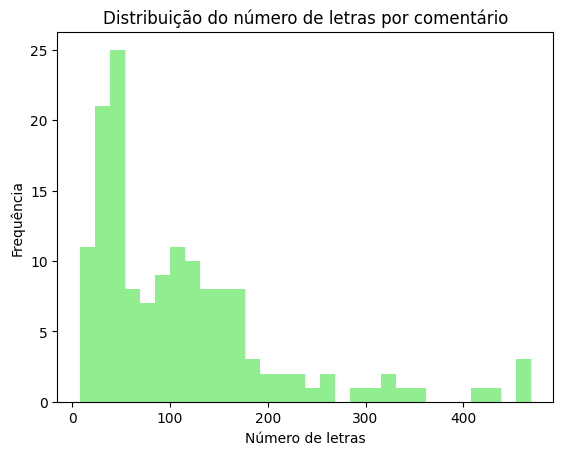

In [40]:
import matplotlib.pyplot as plt

plt.hist(df['num_letters'], bins=30, color='lightgreen')
plt.title('Distribuição do número de letras por comentário')
plt.xlabel('Número de letras')
plt.ylabel('Frequência')
plt.show()